In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#R squared 
from sklearn.metrics import r2_score as R2

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

#features engineering
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import make_regression
from sklearn.model_selection import KFold, cross_validate

#Grid search CV
from sklearn.model_selection import GridSearchCV

sns.set_theme() 

In [2]:
#concrete compressive strength dataset fro kaggle
file_name = "ccs.csv"

data = pd.read_csv(file_name)

df = pd.DataFrame(data)

df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [8]:
#replace outliers (Data cleaning)
df.replace('?', -9999, inplace=True)

#split dataset
X = df.iloc[:, 0: -1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#XGBoost model 
model = XGBRegressor(multi_strategy="multi_output_tree")

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [9]:
#evaluating training and testing data

y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.9967601436101671
0.922778252478301


In [10]:
X_new = [[540.0,	10.0,	100.0,	162.0,	22.5,	1040.0,	676.0,	137]]

prediction = model.predict(X_new)

# print(prediction)
prediction.reshape(-1,1)

array([[70.57908725]])

In [22]:
# Applying K-fold cross-validation and hyperparameter-tuning using GridSearchCV

#k-fold cross validation/ hyperparameter tunning
clf = GridSearchCV(model, {
    'n_estimators': [1, 5, 10, 15, 20, 50 ],
    'random_state': [0, 30,  42],
    # 'learning_rate' : [0.001, 0.01]
}, cv=5, return_train_score=False)


# Fit the model using ONLY the training data
clf.fit(X_train, y_train)

#print results
# clf.cv_results_

#convert to df table format
clf_df = pd.DataFrame(clf.cv_results_)


#required columns
new_clf_df = clf_df[['rank_test_score', 'params', 'mean_test_score']]

new_clf_df

,rank_test_score,params,mean_test_score
0,16,"{'n_estimators': 1, 'random_state': 0}",0.117210
1,16,"{'n_estimators': 1, 'random_state': 30}",0.117210
2,16,"{'n_estimators': 1, 'random_state': 42}",0.117210
3,13,"{'n_estimators': 5, 'random_state': 0}",0.425465
4,14,"{'n_estimators': 5, 'random_state': 30}",0.425465
5,14,"{'n_estimators': 5, 'random_state': 42}",0.425465
6,10,"{'n_estimators': 10, 'random_state': 0}",0.615524
7,11,"{'n_estimators': 10, 'random_state': 30}",0.615524
8,11,"{'n_estimators': 10, 'random_state': 42}",0.615524
9,7,"{'n_estimators': 15, 'random_state': 0}",0.714490


In [23]:
print(clf.best_params_, clf.best_score_)

{'n_estimators': 50, 'random_state': 30} 0.8738358889611988


In [24]:
#replace outliers (Data cleaning)
df.replace('?', -9999, inplace=True)

#split dataset
X = df.iloc[:, 0: -1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#SVR model 
model = GradientBoostingRegressor(n_estimators=50, random_state=30)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",30
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)

In [30]:
#evaluating training and testing data

y_model_train = model.predict(X_train)
y_model_test = model.predict(X_test)

print(R2(y_train, y_model_train))
print(R2(y_test, y_model_test))

0.9182055314861539
0.8476356984148903


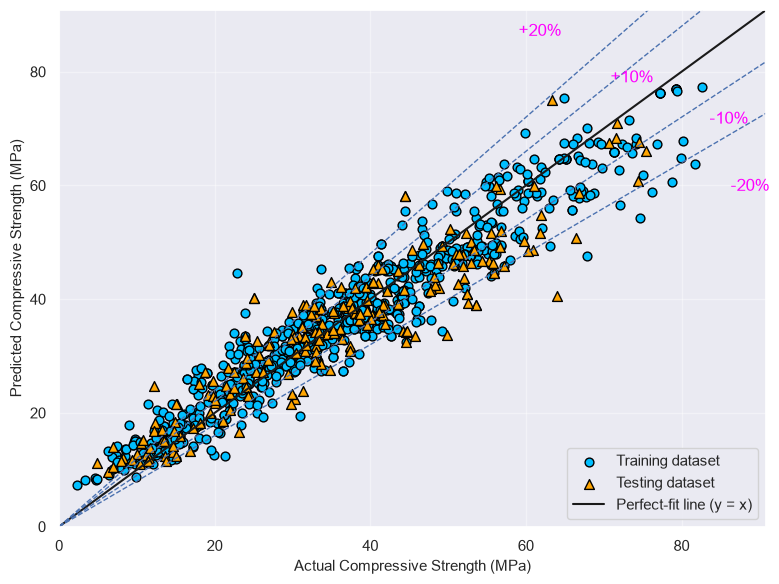

In [33]:
# model visualization

# ==========================
# INPUT YOUR DATA HERE
# ==========================

# Actual values
y_actual_train = y_train
y_actual_test = y_test

# Predicted values (reshaped)
y_pred_train = y_model_train
y_pred_test = y_model_test

# ==========================
# PLOT
# ==========================
plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(y_actual_train, y_pred_train,
            color='deepskyblue',
            edgecolor='black',
            s=40,
            label='Training dataset')

plt.scatter(y_actual_test, y_pred_test,
            color='orange',
            marker='^',
            edgecolor='black',
            s=50,
            label='Testing dataset')

# Axis limits
max_val = max(
    np.max(y_actual_train),
    np.max(y_actual_test),
    np.max(y_pred_train),
    np.max(y_pred_test)
) * 1.1

x = np.linspace(0, max_val, 100)

# Perfect fit line (y=x)
plt.plot(x, x, 'k-', linewidth=1.5, label='Perfect-fit line (y = x)')

# Error bands
plt.plot(x, 1.10*x, 'b--', linewidth=1)
plt.plot(x, 0.90*x, 'b--', linewidth=1)

plt.plot(x, 1.20*x, 'b--', linewidth=1)
plt.plot(x, 0.80*x, 'b--', linewidth=1)

# Labels for error bands
plt.text(max_val*0.78, max_val*0.86, '+10%', color='magenta')
plt.text(max_val*0.92, max_val*0.78, '-10%', color='magenta')

plt.text(max_val*0.65, max_val*0.95, '+20%', color='magenta')
plt.text(max_val*0.95, max_val*0.65, '-20%', color='magenta')

# Formatting
plt.xlabel('Actual Compressive Strength (MPa)', fontsize=11)
plt.ylabel('Predicted Compressive Strength (MPa)', fontsize=11)

# plt.title('Categorical Boosting Regression', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.4)
plt.legend(loc='lower right')

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.tight_layout()
plt.show()

In [36]:
### K-fold cross-validation analysis

# 2. Define the K-Fold strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. List the built-in scoring metrics
# Note: Sklearn metrics follow a "higher is better" rule, so error losses are negative
scoring_metrics = {
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
}

# 4. Perform cross-validation
cv_results = cross_validate(
    model, X, y, cv=kf, scoring=scoring_metrics, n_jobs=-1
)

# 5. Extract, clean, and print the results
print(f"--- 5-Fold Cross-Validation Scores ---")

# MAE (Convert back to positive values)
mae_scores = -cv_results["test_mae"]
print(f"MAE:  {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

# R2 (Already naturally oriented)
r2_scores = cv_results["test_r2"]
print(f"R2:   {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")

# MAPE (Convert back to positive values)
mape_scores = -cv_results["test_mape"]
print(f"MAPE: {mape_scores.mean():.4f} (+/- {mape_scores.std():.4f})")

# RMSE (Convert back to positive values)
rmse_scores = -cv_results["test_rmse"]
print(f"RMSE: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")


--- 5-Fold Cross-Validation Scores ---
MAE:  4.5321 (+/- 0.4070)
R2:   0.8709 (+/- 0.0170)
MAPE: 0.1643 (+/- 0.0074)
RMSE: 5.9827 (+/- 0.6066)


In [40]:
# =========================================
# Predictions
# =========================================

# =========================================
# Training Metrics
# =========================================
train_mae = mean_absolute_error(y_train, y_model_train)
train_mse = mean_squared_error(y_train, y_model_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_model_train)
train_mape = mean_absolute_percentage_error(y_train, y_model_train) * 100

# =========================================
# Testing Metrics
# =========================================
test_mae = mean_absolute_error(y_test, y_model_test)
test_mse = mean_squared_error(y_test, y_model_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_model_test)
test_mape = mean_absolute_percentage_error(y_test, y_model_test) * 100

# =========================================
# Print Results
# =========================================
print("=" * 65)
print(f"{'Metric':<15}{'Training':>15}{'Testing':>15}")
print("=" * 65)

print(f"{'MAE':<15}{train_mae:>15.4f}{test_mae:>15.4f}")
print(f"{'MSE':<15}{train_mse:>15.4f}{test_mse:>15.4f}")
print(f"{'RMSE':<15}{train_rmse:>15.4f}{test_rmse:>15.4f}")
print(f"{'R²':<15}{train_r2:>15.4f}{test_r2:>15.4f}")
print(f"{'MAPE (%)':<15}{train_mape:>15.2f}{test_mape:>15.2f}")

print("=" * 65)

Metric                Training        Testing
MAE                     3.6933         4.8478
MSE                    23.2364        39.2614
RMSE                    4.8204         6.2659
R²                      0.9182         0.8476
MAPE (%)                 13.32          16.18
